In [1]:
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

import okama as ok
import pandas as pd
import matplotlib.pyplot as plt

## Functions

In [2]:
def plot_wealth_distribution(
    first_distribution: pd.DataFrame,
    second_distribution: pd.DataFrame | None = None,
    years=(1, 5, 10),
    percentile=(5, 95),
    bins: int = 40,
    color: str = "#4c78a8",
):
    """Plot wealth distribution for selected forecast horizons.

    Parameters
    ----------
    first_distribution : pd.DataFrame
        First Monte Carlo wealth index where time is expected on rows and
        simulation paths are expected on columns.
    second_distribution : pd.DataFrame | None
        Optional second wealth distribution dataframe. If provided and its shape
        equals the first dataframe, a second row of histograms is plotted.
    years : iterable[int | float] | int | float
        Horizons in years, e.g. (1, 5, 10).
    percentile : tuple[int | float, int | float]
        Two percentile levels for dashed lines. Default is (5, 95).
        The 50th percentile is always shown as a solid line.
    """
    if isinstance(years, (int, float)):
        years = [years]

    years = sorted({float(y) for y in years})
    if not years or any(y <= 0 for y in years):
        raise ValueError("years must contain positive values")

    if not hasattr(percentile, "__iter__"):
        raise TypeError("percentile must contain exactly two values")
    percentile = tuple(percentile)
    if len(percentile) != 2:
        raise ValueError("percentile must contain exactly two values")

    p_low, p_high = sorted(float(p) for p in percentile)
    if p_low < 0 or p_high > 100 or p_low == p_high:
        raise ValueError("percentile values must satisfy: 0 <= low < high <= 100")

    periods_per_year = 12  # okama uses monthly data
    steps = [int(round(y * periods_per_year)) for y in years]
    max_step = max(steps)

    def _prepare_distribution(frame: pd.DataFrame, name: str) -> pd.DataFrame:
        if not isinstance(frame, pd.DataFrame):
            raise TypeError(f"{name} must be a pandas DataFrame")
        if frame.empty:
            raise ValueError(f"{name} is empty")

        index_time_like = isinstance(frame.index, (pd.DatetimeIndex, pd.PeriodIndex))
        columns_time_like = isinstance(frame.columns, (pd.DatetimeIndex, pd.PeriodIndex))

        # If the dataframe is transposed (time in columns), turn it back.
        if (columns_time_like and not index_time_like) or (
            max_step > len(frame.index) - 1 and max_step <= len(frame.columns) - 1
        ):
            frame = frame.T

        if max_step > len(frame.index) - 1:
            max_years = (len(frame.index) - 1) / periods_per_year
            raise ValueError(
                f"Requested horizon is outside {name} range. Max available: {max_years:.2f} years"
            )

        return frame

    first_distribution = _prepare_distribution(first_distribution, "first_distribution")
    distributions = [("df1", first_distribution)]

    if second_distribution is not None:
        second_distribution = _prepare_distribution(second_distribution, "second_distribution")
        if second_distribution.shape != first_distribution.shape:
            raise ValueError("second_distribution must have the same shape as first_distribution")
        distributions.append(("df2", second_distribution))

    nrows = len(distributions)

    # Pre-calculate values for each subplot to make one common X-axis scale.
    subplot_values = {}
    all_values = []
    for row_idx, (dist_label, dist_df) in enumerate(distributions):
        for col_idx, (year, step) in enumerate(zip(years, steps)):
            values = pd.to_numeric(dist_df.iloc[step], errors="coerce").dropna()
            if values.empty:
                raise ValueError(
                    f"No numeric simulation values found for {dist_label} at year={year}"
                )
            subplot_values[(row_idx, col_idx)] = values
            all_values.append(values)

    global_min = min(values.min() for values in all_values)
    global_max = max(values.max() for values in all_values)
    if global_max == global_min:
        pad = abs(global_max) * 0.05 if global_max != 0 else 1.0
    else:
        pad = (global_max - global_min) * 0.02
    x_left, x_right = global_min - pad, global_max + pad

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=len(years),
        figsize=(5 * len(years), 4 * nrows),
        constrained_layout=True,
        squeeze=False,
    )

    for row_idx, (dist_label, dist_df) in enumerate(distributions):
        for col_idx, (year, step) in enumerate(zip(years, steps)):
            ax = axes[row_idx][col_idx]
            values = subplot_values[(row_idx, col_idx)]

            q_low, q50, q_high = values.quantile([p_low / 100, 0.5, p_high / 100])
            spread = q_high - q_low
            range_label = f"{q_low:.0f} - {q_high:.0f}: {spread:.0f}"

            ax.hist(values, bins=bins, range=(x_left, x_right), color=color, alpha=0.85, edgecolor="white")
            ax.axvline(q_low, color="black", linestyle="--", linewidth=1)
            ax.axvline(q50, color="black", linestyle="-", linewidth=1.2)
            ax.axvline(q_high, color="black", linestyle="--", linewidth=1)
            ax.set_xlim(x_left, x_right)

            horizon_label = int(year) if float(year).is_integer() else year
            idx_label = dist_df.index[step]
            ax.set_title(f"{dist_label}: {horizon_label} years ({idx_label})")
            ax.set_xlabel("Wealth index")
            ax.set_ylabel("Frequency")
            ax.grid(alpha=0.25, linestyle=":")

            ax.text(
                0.5,
                -0.20,
                range_label,
                transform=ax.transAxes,
                ha="center",
                va="top",
                clip_on=False,
            )

    return fig, axes


def plot_cagr_distribution(
    first_distribution: pd.DataFrame,
    second_distribution: pd.DataFrame | None = None,
    years=(1, 5, 10),
    percentile=(5, 95),
    bins: int = 40,
    color: str = "#4c78a8",
):
    """Plot CAGR distribution for selected investment horizons.

    Parameters
    ----------
    first_distribution : pd.DataFrame
        First Monte Carlo wealth index where time is expected on rows and
        simulation paths are expected on columns.
    second_distribution : pd.DataFrame | None
        Optional second wealth distribution dataframe. If provided and its shape
        equals the first dataframe, a second row of histograms is plotted.
    years : iterable[int | float] | int | float
        Investment horizons in years, e.g. (1, 5, 10).
    percentile : tuple[int | float, int | float]
        Two percentile levels for dashed lines. Default is (5, 95).
        The 50th percentile is always shown as a solid line.
    """
    if isinstance(years, (int, float)):
        years = [years]

    years = sorted({float(y) for y in years})
    if not years or any(y <= 0 for y in years):
        raise ValueError("years must contain positive values")

    if not hasattr(percentile, "__iter__"):
        raise TypeError("percentile must contain exactly two values")
    percentile = tuple(percentile)
    if len(percentile) != 2:
        raise ValueError("percentile must contain exactly two values")

    p_low, p_high = sorted(float(p) for p in percentile)
    if p_low < 0 or p_high > 100 or p_low == p_high:
        raise ValueError("percentile values must satisfy: 0 <= low < high <= 100")

    periods_per_year = 12  # okama uses monthly data
    steps = [int(round(y * periods_per_year)) for y in years]
    if any(step <= 0 for step in steps):
        raise ValueError("years must be at least one month (1/12)")
    max_step = max(steps)

    def _prepare_distribution(frame: pd.DataFrame, name: str) -> pd.DataFrame:
        if not isinstance(frame, pd.DataFrame):
            raise TypeError(f"{name} must be a pandas DataFrame")
        if frame.empty:
            raise ValueError(f"{name} is empty")

        index_time_like = isinstance(frame.index, (pd.DatetimeIndex, pd.PeriodIndex))
        columns_time_like = isinstance(frame.columns, (pd.DatetimeIndex, pd.PeriodIndex))

        # If the dataframe is transposed (time in columns), turn it back.
        if (columns_time_like and not index_time_like) or (
            max_step > len(frame.index) - 1 and max_step <= len(frame.columns) - 1
        ):
            frame = frame.T

        if max_step > len(frame.index) - 1:
            max_years = (len(frame.index) - 1) / periods_per_year
            raise ValueError(
                f"Requested horizon is outside {name} range. Max available: {max_years:.2f} years"
            )

        return frame

    first_distribution = _prepare_distribution(first_distribution, "first_distribution")
    distributions = [("df1", first_distribution)]

    if second_distribution is not None:
        second_distribution = _prepare_distribution(second_distribution, "second_distribution")
        if second_distribution.shape != first_distribution.shape:
            raise ValueError("second_distribution must have the same shape as first_distribution")
        distributions.append(("df2", second_distribution))

    nrows = len(distributions)

    # Pre-calculate CAGR values for each subplot to make one common X-axis scale.
    subplot_values = {}
    all_values = []
    for row_idx, (dist_label, dist_df) in enumerate(distributions):
        for col_idx, (year, step) in enumerate(zip(years, steps)):
            start_values = pd.to_numeric(dist_df.iloc[0], errors="coerce")
            end_values = pd.to_numeric(dist_df.iloc[step], errors="coerce")
            valid_mask = (start_values > 0) & (end_values > 0)
            cagr_values = ((end_values[valid_mask] / start_values[valid_mask]) ** (1 / year) - 1).dropna()

            if cagr_values.empty:
                raise ValueError(
                    f"No valid CAGR values found for {dist_label} at year={year}. "
                    "CAGR requires positive start and end wealth values."
                )

            subplot_values[(row_idx, col_idx)] = cagr_values
            all_values.append(cagr_values)

    global_min = min(values.min() for values in all_values)
    global_max = max(values.max() for values in all_values)
    if global_max == global_min:
        pad = abs(global_max) * 0.05 if global_max != 0 else 0.01
    else:
        pad = (global_max - global_min) * 0.02
    x_left, x_right = global_min - pad, global_max + pad

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=len(years),
        figsize=(5 * len(years), 4 * nrows),
        constrained_layout=True,
        squeeze=False,
    )

    for row_idx, (dist_label, dist_df) in enumerate(distributions):
        for col_idx, (year, step) in enumerate(zip(years, steps)):
            ax = axes[row_idx][col_idx]
            cagr_values = subplot_values[(row_idx, col_idx)]

            q_low, q50, q_high = cagr_values.quantile([p_low / 100, 0.5, p_high / 100])
            spread = q_high - q_low
            range_label = f"{q_low:.2%} - {q_high:.2%}: {spread:.2%}"

            ax.hist(cagr_values, bins=bins, range=(x_left, x_right), color=color, alpha=0.85, edgecolor="white")
            ax.axvline(q_low, color="black", linestyle="--", linewidth=1)
            ax.axvline(q50, color="black", linestyle="-", linewidth=1.2)
            ax.axvline(q_high, color="black", linestyle="--", linewidth=1)
            ax.set_xlim(x_left, x_right)

            horizon_label = int(year) if float(year).is_integer() else year
            idx_label = dist_df.index[step]
            ax.set_title(f"{dist_label}: CAGR for {horizon_label} years ({idx_label})")
            ax.set_xlabel("CAGR")
            ax.set_ylabel("Frequency")
            ax.grid(alpha=0.25, linestyle=":")

            ax.text(
                0.5,
                -0.20,
                range_label,
                transform=ax.transAxes,
                ha="center",
                va="top",
                clip_on=False,
            )

    return fig, axes


In [9]:
assets = ["SPY.US", "AGG.US", "GC.COMM"]

## Aggressive

In [10]:
pf1 = ok.Portfolio(
    assets, 
    weights=[.70, .15, .15], 
    ccy="USD", 
    inflation=True, 
    rebalancing_strategy=ok.Rebalance(period='year'))
pf1

symbol                               portfolio_9192.PF
assets                       [SPY.US, AGG.US, GC.COMM]
weights                              [0.7, 0.15, 0.15]
rebalancing_period                                year
rebalancing_abs_deviation                         None
rebalancing_rel_deviation                         None
currency                                           USD
inflation                                     USD.INFL
first_date                                     2003-10
last_date                                      2025-12
period_length                       22 years, 3 months
dtype: object

In [11]:
pf1.get_cagr()

portfolio_9192.PF    0.102391
USD.INFL             0.025617
dtype: float64

In [12]:
pf1.risk_annual[-1]

np.float64(0.11907042296601497)

In [13]:
pf1.dcf.mc.kstest_for_all_distributions

,statistic,p-value
norm,0.068403,0.158393
lognorm,0.074749,0.097238
t,0.042787,0.698287


In [14]:
pf1.dcf.set_mc_parameters(
    distribution="t",  # Student's t-distribution
    # distribution_parameters=(None, None),
    period=20,  # the forecasting period is 60 years
    mc_number=400,  # generate 400 random simulations
)

In [15]:
pf1.dcf.mc.optimize_df_for_students(var_level=5)

4.262038479685701

In [16]:
pf1.dcf.mc.distribution_parameters = (4.26, None, None)

In [17]:
pf1.dcf.mc

Portfolio symbol                            portfolio_9192.PF
Monte Carlo distribution                                    t
Distribution parameters                    (4.26, None, None)
Distribution parameters after resolving    (4.26, 0.01, 0.03)
Monte Carlo period                                         20
Monte Carlo number                                        400
dtype: object

In [18]:
df1 = pf1.dcf.monte_carlo_wealth(discounting="pv")

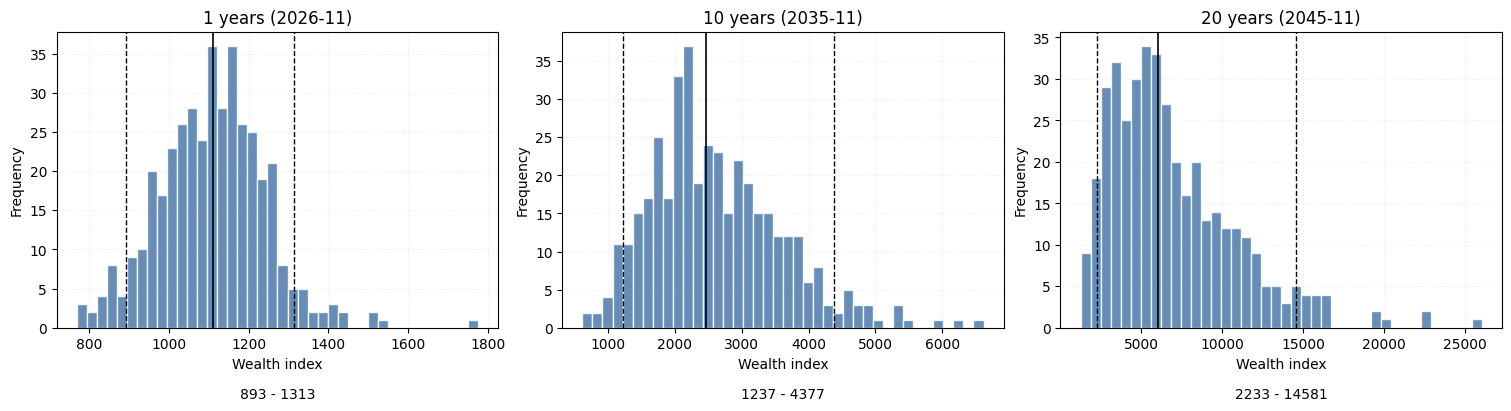

In [19]:
plot_wealth_distribution(df1, years=[1, 10, 20]);

## Conservative

In [20]:
assets

['SPY.US', 'AGG.US', 'GC.COMM']

In [21]:
pf2 = ok.Portfolio(
    assets, 
    weights=[.15, .70, .15], 
    ccy="USD", 
    inflation=True, 
    rebalancing_strategy=ok.Rebalance(period='year'))
pf2

symbol                               portfolio_3973.PF
assets                       [SPY.US, AGG.US, GC.COMM]
weights                              [0.15, 0.7, 0.15]
rebalancing_period                                year
rebalancing_abs_deviation                         None
rebalancing_rel_deviation                         None
currency                                           USD
inflation                                     USD.INFL
first_date                                     2003-10
last_date                                      2025-12
period_length                       22 years, 3 months
dtype: object

In [22]:
pf2.get_cagr()

portfolio_3973.PF    0.058852
USD.INFL             0.025617
dtype: float64

In [24]:
pf2.risk_annual[-1]

np.float64(0.05830476478795537)

In [25]:
pf2.dcf.mc.kstest_for_all_distributions

,statistic,p-value
norm,0.052637,0.437615
lognorm,0.053963,0.406456
t,0.023171,0.998253


In [26]:
pf2.dcf.set_mc_parameters(
    distribution="t",  # Student's t-distribution
    # distribution_parameters=(None, None),
    period=20,  # the forecasting period is 60 years
    mc_number=400,  # generate 400 random simulations
)

In [30]:
y2 = pf2.dcf.mc.optimize_df_for_students(var_level=5)

In [31]:
pf1.dcf.mc.distribution_parameters = (y2, None, None)

In [32]:
pf2.dcf.mc

Portfolio symbol                            portfolio_3973.PF
Monte Carlo distribution                                    t
Distribution parameters                                  None
Distribution parameters after resolving    (4.87, 0.01, 0.01)
Monte Carlo period                                         20
Monte Carlo number                                        400
dtype: object

In [34]:
df2 = pf2.dcf.monte_carlo_wealth(discounting="pv")

## Plots

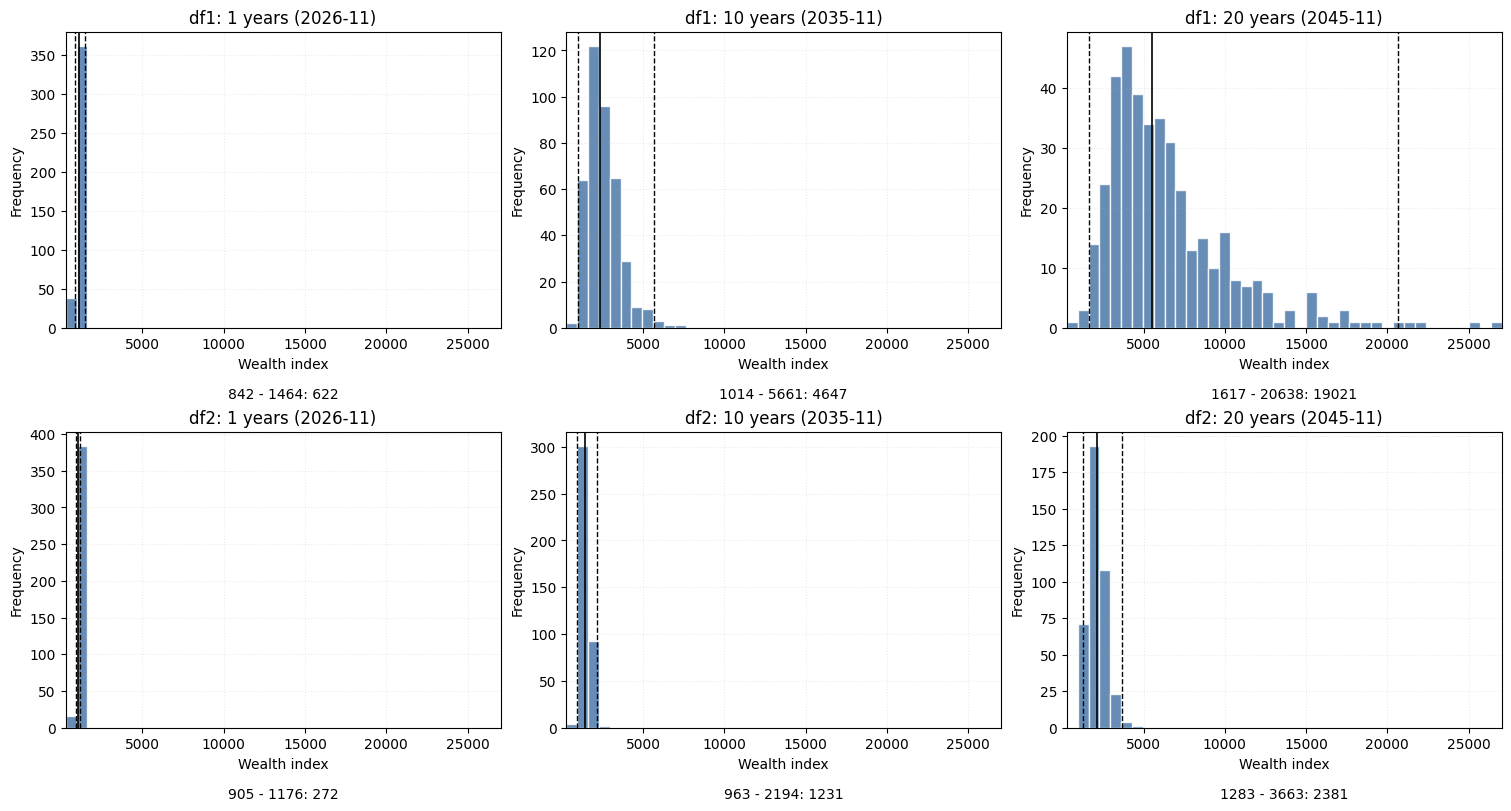

In [48]:
plot_wealth_distribution(df1, second_distribution=df2, years=[1, 10, 20], percentile=[1, 99]);

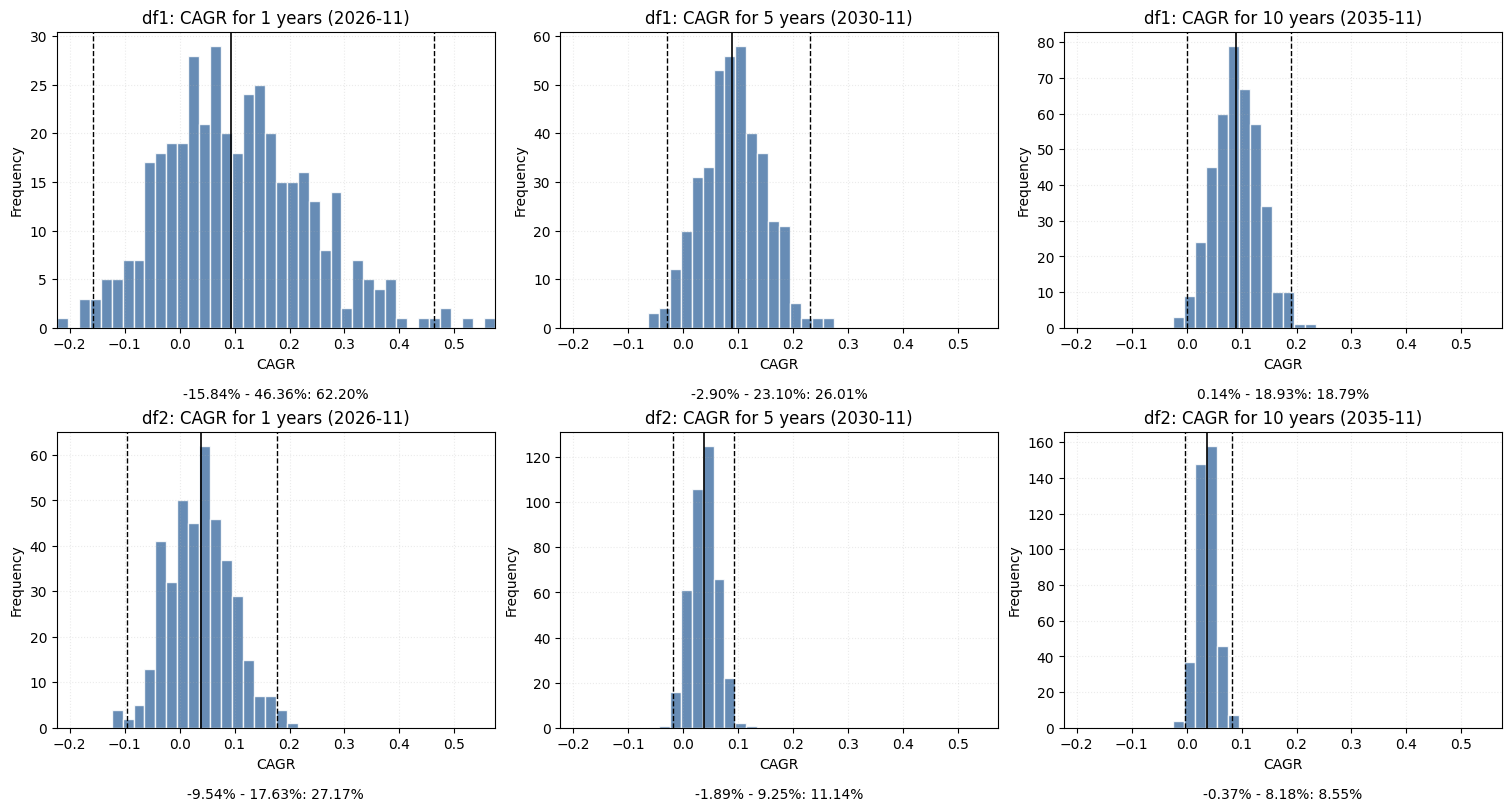

In [49]:
plot_cagr_distribution(df1, second_distribution=df2, years=[1, 5, 10], percentile=[1, 99]);